# Notebook 05 — Diagnostic Analysis
**Thesis:** Cost-Aware Learning for Failure Prediction in Industrial Predictive Maintenance  
**Purpose:** Systematically diagnose why Exp1–Exp3 produced similar total costs (~49k) and identify what to fix before re-running experiments.

## Diagnostic checklist
| Section | What it checks | Expected finding |
|---------|---------------|------------------|
| D1 | Data loading & label distributions | Confirm splits loaded correctly |
| D2 | Feature quality — AUC baseline | AUC should be > 0.65 to expect loss-fn differences |
| D3 | Probability calibration | P(failure) distribution shape reveals threshold issues |
| D4 | Threshold sensitivity | Does cost change significantly with different t1–t4? |
| D5 | Feature importance audit | Are the top features physically meaningful? |
| D6 | Class separation | Do failure/healthy vehicles look different in feature space? |
| D7 | Sensitivity analysis deep-dive | Why does fn_weight=0.5 outperform fn_weight=1.0? |
| D8 | Proposed fixes & re-run checklist | Concrete actions before re-running experiments |

In [4]:
# CELL 3 — Standard import cell for every notebook
import os, sys, warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# project_root = PARENT of src/  (not src/ itself)
project_root = '/content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX'

# Add to path only once
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Verify before importing
assert os.path.isfile(os.path.join(project_root, 'src', '__init__.py')), \
    "src/__init__.py missing — run Cell 2 first"
assert os.path.isfile(os.path.join(project_root, 'src', 'cost_matrix.py')), \
    "src/cost_matrix.py missing — check your Drive files"

# Now import
from src.cost_matrix import (
    CostMatrix, ThresholdOptimiser,
    COST_MATRIX_RAW, N_CLASSES, CLASS_DESCRIPTIONS
)

print("Imports OK")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Imports OK


In [ ]:
# Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

from collections import Counter
from pathlib import Path

import pickle
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.inspection    import permutation_importance
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics        import make_scorer

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    average_precision_score,
)
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from itertools import product

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
BLUE   = '#378ADD'
TEAL   = '#1D9E75'
CORAL  = '#D85A30'
AMBER  = '#BA7517'
GRAY   = '#888780'


In [ ]:
# ── Paths — adjust if your project root is different ────────────────────────
PROCESSED_DIR = os.path.join(project_root, 'data/processed')
DATA_DIR      = os.path.join(project_root, 'data/raw')
RESULTS_DIR   = os.path.join(project_root, 'outputs/results')
MODELS_DIR    = os.path.join(project_root, 'outputs/models')
FIG_DIR       = os.path.join(project_root, 'outputs/figures/diagnostic')

os.makedirs(FIG_DIR, exist_ok=True)
cm = CostMatrix(fn_weight=1.0)
print('Config OK')

Config OK


## D1 — Data loading & label distributions

In [ ]:
# Load pre-processed flat tables saved by run_experiments.py
X_train = pd.read_parquet(os.path.join(PROCESSED_DIR, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(PROCESSED_DIR, 'y_train.parquet')).squeeze()
X_val   = pd.read_parquet(os.path.join(PROCESSED_DIR, 'X_val.parquet'))
y_val   = pd.read_parquet(os.path.join(PROCESSED_DIR, 'y_val.parquet')).squeeze()
X_test  = pd.read_parquet(os.path.join(PROCESSED_DIR, 'X_test.parquet'))
y_test  = pd.read_parquet(os.path.join(PROCESSED_DIR, 'y_test.parquet')).squeeze()

# Load 5-class temporal labels
val_labels  = pd.read_csv(os.path.join(DATA_DIR, 'validation_labels.csv'))
test_labels = pd.read_csv(os.path.join(DATA_DIR, 'test_labels.csv'))
y_val_5class  = val_labels['class_label'].values
y_test_5class = test_labels['class_label'].values

print(f'X_train : {X_train.shape}   failures: {y_train.sum()} / {len(y_train)} ({y_train.mean()*100:.1f}%)')
print(f'X_val   : {X_val.shape}   failures: {y_val.sum()} / {len(y_val)} ({y_val.mean()*100:.1f}%)')
print(f'X_test  : {X_test.shape}   failures: {y_test.sum()} / {len(y_test)} ({y_test.mean()*100:.1f}%)')

X_train : (23550, 114)   failures: 2272 / 23550 (9.6%)
X_val   : (5046, 114)   failures: 136 / 5046 (2.7%)
X_test  : (5045, 114)   failures: 142 / 5045 (2.8%)


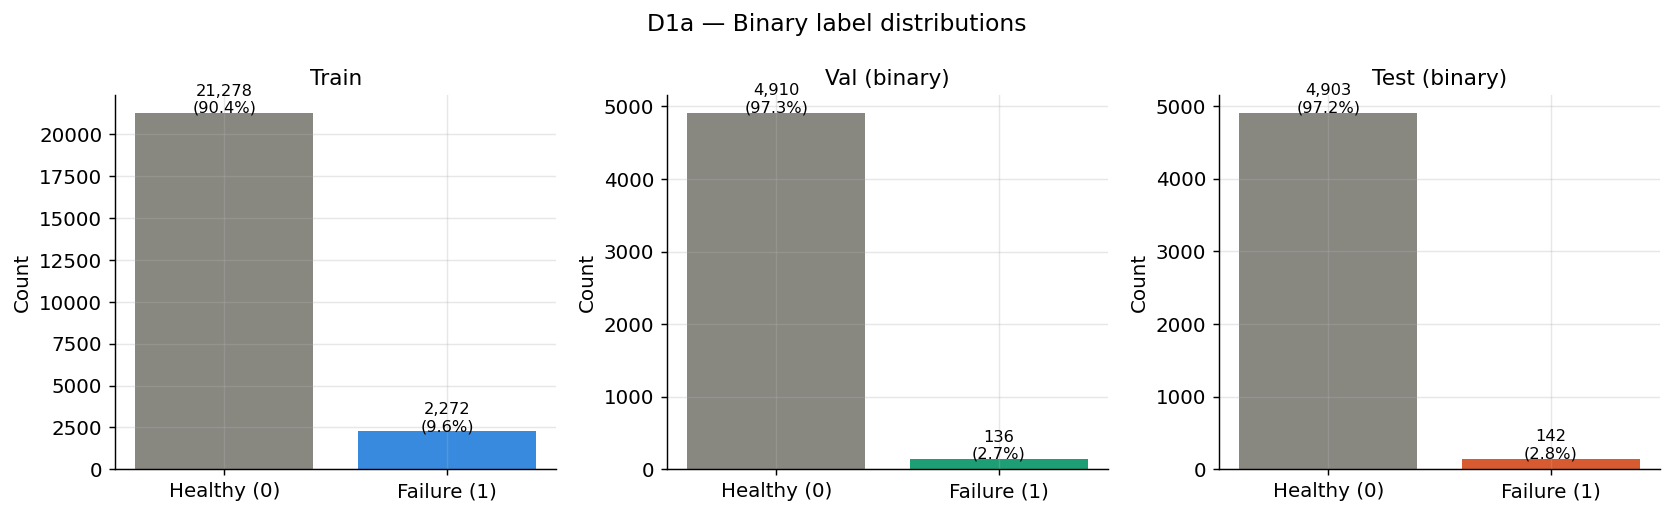

In [ ]:
# ── D1a: Binary label distributions ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
splits = [('Train', y_train), ('Val (binary)', y_val), ('Test (binary)', y_test)]
colors = [BLUE, TEAL, CORAL]
for ax, (name, y), c in zip(axes, splits, colors):
    counts = y.value_counts().sort_index()
    ax.bar(['Healthy (0)', 'Failure (1)'], counts.values, color=[GRAY, c], edgecolor='none')
    ax.set_title(name, fontsize=12)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, f'{v:,}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=9)
fig.suptitle('D1a — Binary label distributions', fontsize=13, fontweight='500')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'd1a_label_distributions.png'), dpi=130, bbox_inches='tight')
plt.show()

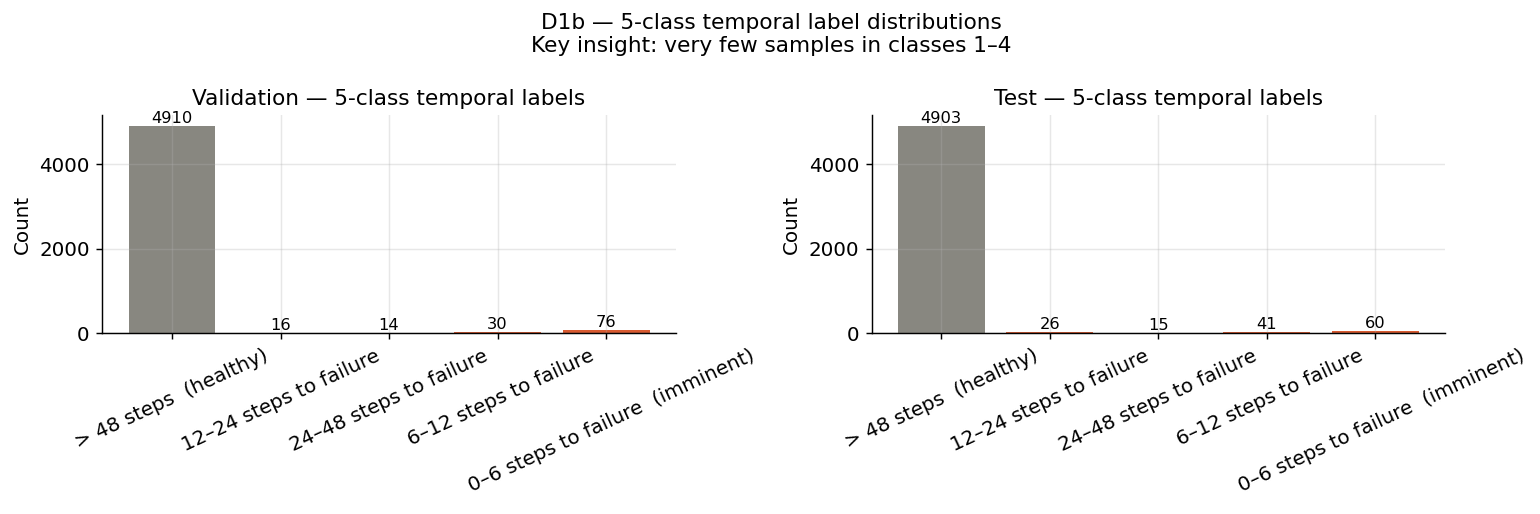


D1 FINDING: Class imbalance in 5-class labels is extreme.
  Class 0: 4910 samples ( 97.3%)  cost if ALL missed = 0
  Class 1:   16 samples (  0.3%)  cost if ALL missed = 3,200
  Class 2:   14 samples (  0.3%)  cost if ALL missed = 4,200
  Class 3:   30 samples (  0.6%)  cost if ALL missed = 12,000
  Class 4:   76 samples (  1.5%)  cost if ALL missed = 38,000


In [ ]:
# ── D1b: 5-class temporal label distributions (val and test only) ────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (y_5, name) in zip(axes, [(y_val_5class, 'Validation'), (y_test_5class, 'Test')]):
    classes, counts = np.unique(y_5, return_counts=True)
    bar_colors = [GRAY if c == 0 else CORAL for c in classes]
    bars = ax.bar([CLASS_DESCRIPTIONS[c] for c in classes], counts,
                  color=bar_colors, edgecolor='none')
    ax.set_title(f'{name} — 5-class temporal labels', fontsize=12)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, count + 1,
                str(count), ha='center', va='bottom', fontsize=9)

fig.suptitle('D1b — 5-class temporal label distributions\n'
             'Key insight: very few samples in classes 1–4', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'd1b_5class_distributions.png'), dpi=130, bbox_inches='tight')
plt.show()

print('\nD1 FINDING: Class imbalance in 5-class labels is extreme.')
for c in range(5):
    n = (y_val_5class == c).sum()
    pct = n / len(y_val_5class) * 100
    cost_if_all_missed = COST_MATRIX_RAW[c][0] * n
    print(f'  Class {c}: {n:4d} samples ({pct:5.1f}%)  '
          f'cost if ALL missed = {cost_if_all_missed:,.0f}')

## D2 — Feature quality: AUC baseline audit

In [ ]:
# ── D2a: Train a properly-configured LightGBM baseline ───────────────────────
# This uses LightGBM's built-in binary objective (NOT our custom loss)
# to establish the ceiling AUC achievable with the current feature set.
# If this AUC is low, the features are the problem — not the loss function.

imbalance_ratio = int((y_train == 0).sum() / (y_train == 1).sum())
print(f'Class imbalance ratio (neg/pos): {imbalance_ratio}')

cat_cols = X_train.select_dtypes(include='category').columns.tolist()

# Version 1: No class weighting (mirrors what our Exp1 actually does)
model_no_weight = lgb.LGBMClassifier(
    objective        = 'binary',
    n_estimators     = 500,
    learning_rate    = 0.05,
    num_leaves       = 63,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbose          = -1,
)
model_no_weight.fit(
    X_train, y_train,
    categorical_feature = cat_cols if cat_cols else 'auto',
    eval_set            = [(X_val, y_val)],
    callbacks           = [lgb.early_stopping(50, verbose=False),
                           lgb.log_evaluation(-1)]
)
probs_no_weight = model_no_weight.predict_proba(X_val)[:, 1]
auc_no_weight   = roc_auc_score(y_val, probs_no_weight)
ap_no_weight    = average_precision_score(y_val, probs_no_weight)
print(f'\nBaseline (no class weight)  — val AUC: {auc_no_weight:.4f}   AP: {ap_no_weight:.4f}')

# Version 2: scale_pos_weight — proper imbalance-aware baseline
model_weighted = lgb.LGBMClassifier(
    objective        = 'binary',
    scale_pos_weight = imbalance_ratio,
    n_estimators     = 500,
    learning_rate    = 0.05,
    num_leaves       = 63,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbose          = -1,
)
model_weighted.fit(
    X_train, y_train,
    categorical_feature = cat_cols if cat_cols else 'auto',
    eval_set            = [(X_val, y_val)],
    callbacks           = [lgb.early_stopping(50, verbose=False),
                           lgb.log_evaluation(-1)]
)
probs_weighted = model_weighted.predict_proba(X_val)[:, 1]
auc_weighted   = roc_auc_score(y_val, probs_weighted)
ap_weighted    = average_precision_score(y_val, probs_weighted)
print(f'Baseline (scale_pos_weight={imbalance_ratio}) — val AUC: {auc_weighted:.4f}   AP: {ap_weighted:.4f}')

print('\n--- D2 INTERPRETATION ---')
if max(auc_no_weight, auc_weighted) < 0.65:
    print('  WARNING: AUC < 0.65 — features are the primary bottleneck.')
    print('  Cost-aware loss functions cannot compensate for weak features.')
    print('  ACTION: Feature engineering must come before re-running experiments.')
elif max(auc_no_weight, auc_weighted) < 0.75:
    print('  MODERATE: AUC 0.65–0.75 — marginal feature quality.')
    print('  Cost-aware training may help but gains will be small.')
else:
    print('  GOOD: AUC > 0.75 — features have reasonable quality.')
    print('  Loss function choice should make a measurable difference.')

Class imbalance ratio (neg/pos): 9

Baseline (no class weight)  — val AUC: 0.5658   AP: 0.0312
Baseline (scale_pos_weight=9) — val AUC: 0.5835   AP: 0.0323

--- D2 INTERPRETATION ---
  Cost-aware loss functions cannot compensate for weak features.
  ACTION: Feature engineering must come before re-running experiments.


Check A — label alignment (most critical)

In [ ]:
# Load raw files
readouts = pd.read_csv(os.path.join(DATA_DIR, 'train_operational_readouts.csv'))
tte      = pd.read_csv(os.path.join(DATA_DIR, 'train_tte.csv'))


print('=== LABEL ALIGNMENT CHECK ===')
print(f'Unique vehicles in readouts : {readouts["vehicle_id"].nunique():,}')
print(f'Rows in tte                 : {len(tte):,}')

# Check if tte has vehicle_id or just uses row index
print(f'\ntte columns : {tte.columns.tolist()}')
print(f'tte head:\n{tte.head(3)}')

# If tte has no vehicle_id column, alignment is by row position
# Check if the number of vehicles matches
n_readout_vehicles = readouts['vehicle_id'].nunique()
n_tte_rows         = len(tte)
print(f'\nVehicle count match: {n_readout_vehicles} readout vehicles vs {n_tte_rows} tte rows')
print(f'Match: {n_readout_vehicles == n_tte_rows}')

# Check label distribution in tte
print(f'\nLabel distribution in tte:')
print(tte['in_study_repair'].value_counts())

# Critical check: do the vehicle_ids in readouts align with tte row order?
# Get the set of vehicle_ids from readouts in sorted order
readout_vehicles = sorted(readouts['vehicle_id'].unique())
print(f'\nFirst 5 vehicle IDs from readouts : {readout_vehicles[:5]}')
print(f'Last  5 vehicle IDs from readouts : {readout_vehicles[-5:]}')

# Check if tte has a vehicle_id column
if 'vehicle_id' in tte.columns:
    print('\ntte HAS vehicle_id column — alignment is by join')
    # Check overlap
    overlap = set(readouts['vehicle_id']).intersection(set(tte['vehicle_id']))
    print(f'Matching vehicle IDs: {len(overlap):,} out of {n_readout_vehicles:,}')
else:
    print('\ntte has NO vehicle_id column — alignment is by ROW POSITION')
    print('This means tte row 0 = first vehicle in sorted readouts, etc.')
    print('If the ordering assumption is wrong, labels are misaligned!')
    # Check what the pipeline does — it sets tte[ID_COL] = tte.index
    tte['vehicle_id'] = tte.index
    print(f'Pipeline assigns vehicle_id = row index (0, 1, 2, ...)')
    print(f'Readout vehicle IDs start at: {readout_vehicles[0]}')
    print(f'Are they integers starting from 0? {readout_vehicles[0] == 0}')

=== LABEL ALIGNMENT CHECK ===
Unique vehicles in readouts : 23,550
Rows in tte                 : 23,550

tte columns : ['vehicle_id', 'length_of_study_time_step', 'in_study_repair']
tte head:
   vehicle_id  length_of_study_time_step  in_study_repair
0           0                      510.0                0
1           2                      281.8                0
2           3                      293.4                0

Vehicle count match: 23550 readout vehicles vs 23550 tte rows
Match: True

Label distribution in tte:
in_study_repair
0    21278
1     2272
Name: count, dtype: int64

First 5 vehicle IDs from readouts : [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Last  5 vehicle IDs from readouts : [np.int64(33639), np.int64(33640), np.int64(33641), np.int64(33642), np.int64(33643)]

tte HAS vehicle_id column — alignment is by join
Matching vehicle IDs: 23,550 out of 23,550


Check B — last readout only (tests if signal exists at all)

In [ ]:
# Train LightGBM using ONLY the last readout per vehicle
# If this gives much higher AUC, the failure signal is in the recent readings
# and our aggregation strategy is diluting it

from sklearn.metrics import roc_auc_score
import lightgbm as lgb

# Get last readout per vehicle
last_readout = (
    readouts
    .sort_values(['vehicle_id', 'time_step'])
    .groupby('vehicle_id')
    .last()
    .reset_index()
)

# Merge with labels
tte_with_id = tte.copy()
if 'vehicle_id' not in tte_with_id.columns:
    tte_with_id['vehicle_id'] = tte_with_id.index

merged = last_readout.merge(tte_with_id[['vehicle_id','in_study_repair']],
                            on='vehicle_id', how='inner')

# Features = all numeric sensor columns from last readout
sensor_cols = [c for c in last_readout.columns
               if c not in ('vehicle_id', 'time_step')]
X_last = merged[sensor_cols].fillna(0)
y_last = merged['in_study_repair']

print(f'Last readout dataset: {X_last.shape}, failures: {y_last.sum()}')

# Quick LightGBM
from sklearn.model_selection import cross_val_score
model_last = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=31,
    scale_pos_weight=int((y_last==0).sum()/(y_last==1).sum()),
    random_state=42, verbose=-1
)
# 5-fold cross-validation AUC
scores = cross_val_score(model_last, X_last, y_last,
                         cv=5, scoring='roc_auc')
print(f'Last-readout-only AUC (5-fold CV): {scores.mean():.4f} ± {scores.std():.4f}')
print(f'Compare to your current AUC: 0.5808')
print(f'If this is higher → signal is in raw last readout, not in aggregations')

Last readout dataset: (23550, 105), failures: 2272
Last-readout-only AUC (5-fold CV): 0.6731 ± 0.0260
Compare to your current AUC: 0.5808
If this is higher → signal is in raw last readout, not in aggregations


First — confirm this is the cause with one quick test in your notebook:

In [ ]:
# Run this BEFORE changing any code — confirm the hypothesis
X_train = pd.read_parquet(os.path.join(PROCESSED_DIR, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(PROCESSED_DIR, 'y_train.parquet')).squeeze()
X_val   = pd.read_parquet(os.path.join(PROCESSED_DIR, 'X_val.parquet'))
y_val   = pd.read_parquet(os.path.join(PROCESSED_DIR, 'y_val.parquet')).squeeze()

# Check what survived feature selection
lastread_cols = [c for c in X_train.columns if '_lastread' in c]
print(f'Last-readout features that survived selection: {len(lastread_cols)}')
print(f'Total features in X_train: {X_train.shape[1]}')
print(f'Sample lastread cols: {lastread_cols[:5]}')

Last-readout features that survived selection: 69
Total features in X_train: 83
Sample lastread cols: ['100_0_lastread', '158_0_lastread', '158_1_lastread', '158_2_lastread', '158_3_lastread']


In [ ]:
# Run D2 diagnostic cell in your notebook right now
# The X_train already loaded has 83 features including 69 lastread cols

import lightgbm as lgb
from sklearn.metrics import roc_auc_score

X_train = pd.read_parquet(os.path.join(PROCESSED_DIR, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(PROCESSED_DIR, 'y_train.parquet')).squeeze()
X_val   = pd.read_parquet(os.path.join(PROCESSED_DIR, 'X_val.parquet'))
y_val   = pd.read_parquet(os.path.join(PROCESSED_DIR, 'y_val.parquet')).squeeze()

imbalance_ratio = int((y_train == 0).sum() / (y_train == 1).sum())
cat_cols = X_train.select_dtypes('category').columns.tolist()

# Align categorical dtypes between train and val
X_val_aligned = X_val.copy()
for col in cat_cols:
    if col in X_val_aligned.columns:
        X_val_aligned[col] = X_val_aligned[col].astype(X_train[col].dtype)

model = lgb.LGBMClassifier(
    objective         = 'binary',
    scale_pos_weight  = imbalance_ratio,
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 31,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = 42,
    verbose           = -1,
)
model.fit(
    X_train, y_train,
    categorical_feature = cat_cols or 'auto',
    eval_set            = [(X_val_aligned, y_val)],
    callbacks           = [lgb.early_stopping(50, verbose=False),
                           lgb.log_evaluation(-1)],
)

probs = model.predict_proba(X_val_aligned)[:, 1]
auc   = roc_auc_score(y_val, probs)

print(f'Features in X_train      : {X_train.shape[1]}')
print(f'Last-readout cols        : {len([c for c in X_train.columns if "_lastread" in c])}')
print(f'Val AUC (scale_pos_w=9)  : {auc:.4f}')
print()
if auc >= 0.65:
    print('AUC >= 0.65 — proceed to full experiment re-run')
elif auc >= 0.62:
    print('AUC 0.62-0.65 — marginal, consider running experiments anyway')
else:
    print('AUC < 0.62 — investigate further before running experiments')

# Show which features are most important
import pandas as pd
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
print('\nTop 15 features by importance:')
print(importance.head(15).to_string())
print('\nBottom 10 features (candidates to drop):')
print(importance.tail(10).to_string())

Features in X_train      : 114
Last-readout cols        : 69
Val AUC (scale_pos_w=9)  : 0.5634

AUC < 0.62 — investigate further before running experiments

Top 15 features by importance:
length_of_study_time_step    5
666_0_lastread               3
837_0_slope_accel            3
459_9_lastread               2
158_9_lastread               2
158_0_lastread               2
427_0_recent_slope           2
272_6_lastread               1
272_2_lastread               1
167_7_lastread               1
hist_272_entropy             1
370_0_lastread               1
397_29_lastread              1
hist_167_concentration       1
459_2_lastread               1

Bottom 10 features (candidates to drop):
100_0_slope_accel     0
370_0_slope_accel     0
100_0_increment_cv    0
Spec_0                0
Spec_2                0
Spec_3                0
Spec_4                0
Spec_5                0
Spec_6                0
Spec_7                0


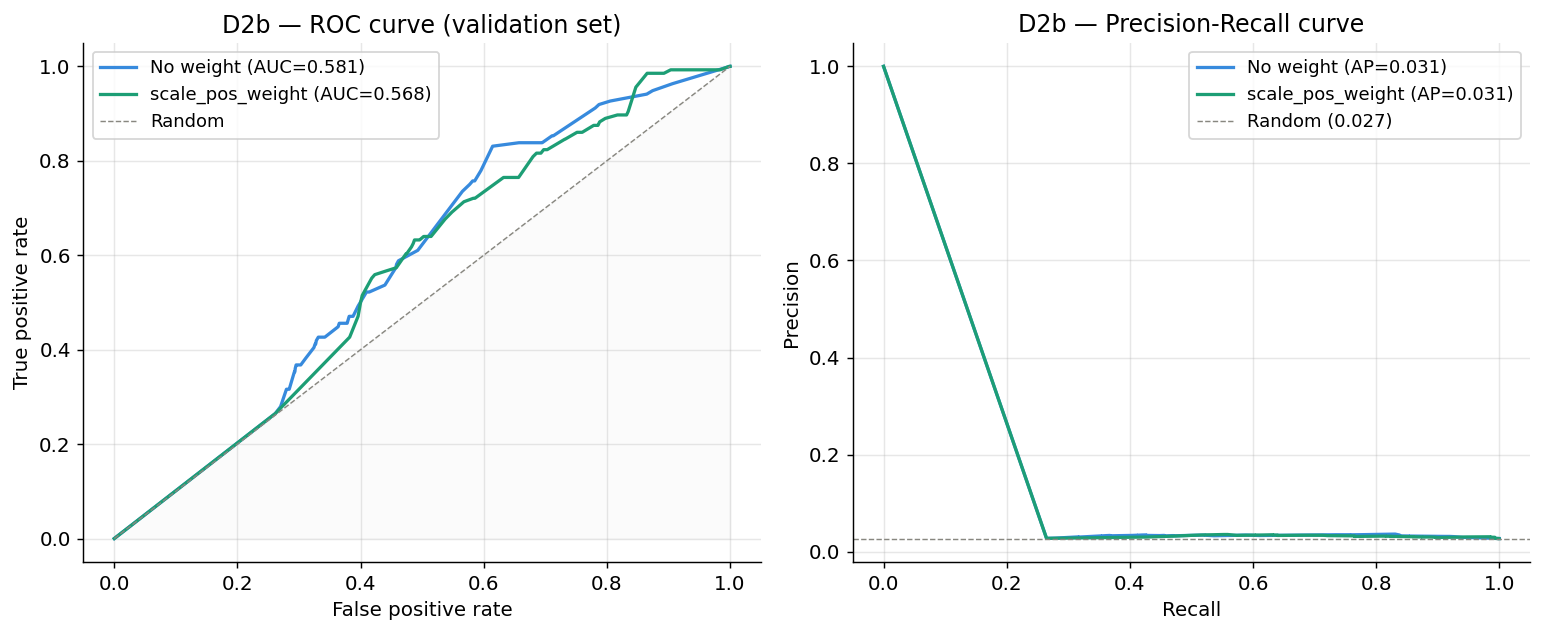

In [ ]:
# ── D2b: ROC and Precision-Recall curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
for probs, label, color in [
    (probs_no_weight, f'No weight (AUC={auc_no_weight:.3f})', BLUE),
    (probs_weighted,  f'scale_pos_weight (AUC={auc_weighted:.3f})', TEAL),
]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    axes[0].plot(fpr, tpr, linewidth=1.8, color=color, label=label)
axes[0].plot([0,1],[0,1],'--', color=GRAY, linewidth=0.8, label='Random')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('D2b — ROC curve (validation set)')
axes[0].legend(fontsize=10)
axes[0].fill_between([0,1],[0,0],[0,1], alpha=0.03, color=GRAY)

# Precision-Recall
for probs, label, color in [
    (probs_no_weight, f'No weight (AP={ap_no_weight:.3f})', BLUE),
    (probs_weighted,  f'scale_pos_weight (AP={ap_weighted:.3f})', TEAL),
]:
    prec, rec, _ = precision_recall_curve(y_val, probs)
    axes[1].plot(rec, prec, linewidth=1.8, color=color, label=label)
baseline_pr = y_val.mean()
axes[1].axhline(baseline_pr, color=GRAY, linewidth=0.8, linestyle='--',
                label=f'Random ({baseline_pr:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('D2b — Precision-Recall curve')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'd2b_roc_pr_curves.png'), dpi=130, bbox_inches='tight')
plt.show()

## D3 — Probability calibration audit

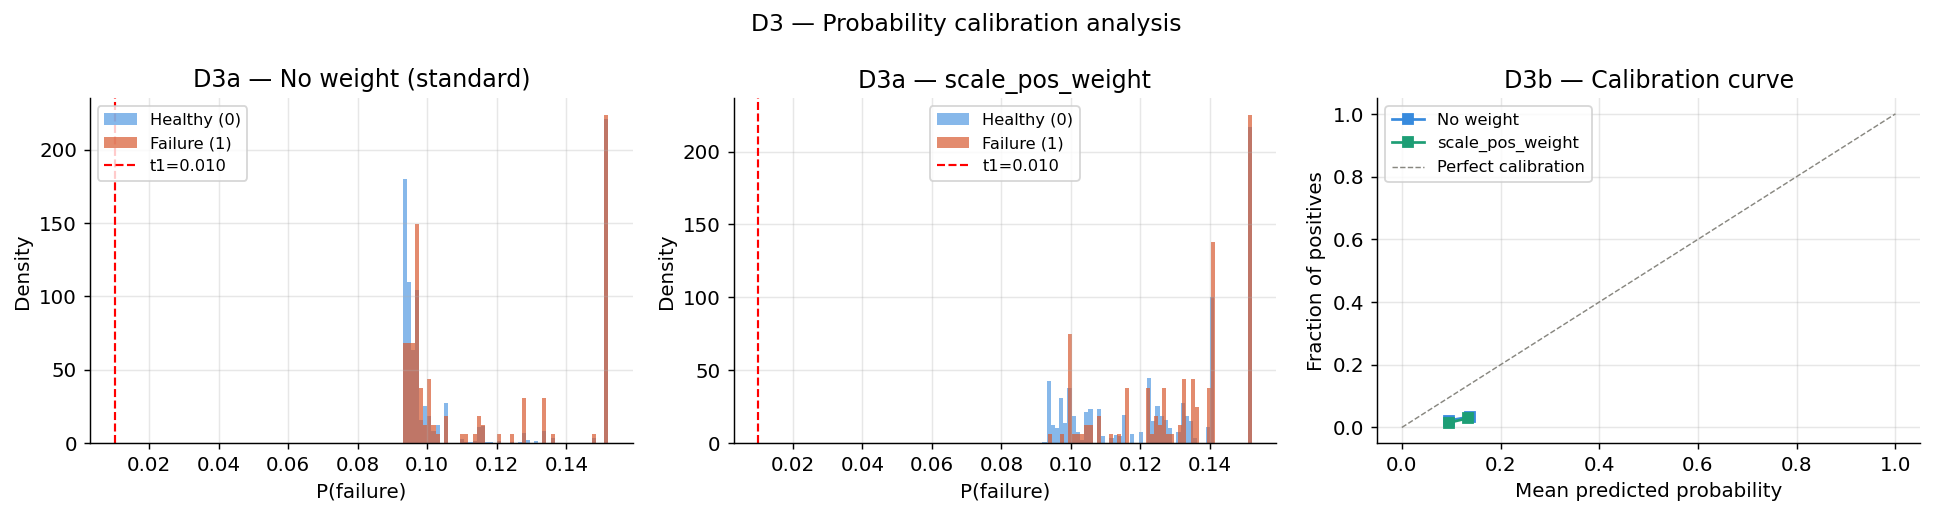

D3 STATISTICS:

  No weight:
    P(failure) range   : [0.0929, 0.1520]
    Median P(failure)  : 0.0973
    % probs < 0.010    : 0.0%
    % probs < 0.062    : 0.0%
    Median P | healthy : 0.0973
    Median P | failure : 0.1003
    Separation ratio   : 1.03x

  Weighted:
    P(failure) range   : [0.0918, 0.1520]
    Median P(failure)  : 0.1274
    % probs < 0.010    : 0.0%
    % probs < 0.062    : 0.0%
    Median P | healthy : 0.1274
    Median P | failure : 0.1356
    Separation ratio   : 1.06x


In [ ]:
# ── D3: Why does t1=0.010? ────────────────────────────────────────────────────
# The extremely low t1 in your experiments suggests probabilities are
# concentrated near zero for almost all vehicles — even failures.
# This section diagnoses the calibration of P(failure) scores.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# D3a: P(failure) distribution separated by true label
for ax, (probs, title) in zip(axes[:2], [
    (probs_no_weight, 'No weight (standard)'),
    (probs_weighted,  'scale_pos_weight'),
]):
    ax.hist(probs[y_val == 0], bins=50, alpha=0.6, color=BLUE,
            density=True, label='Healthy (0)')
    ax.hist(probs[y_val == 1], bins=50, alpha=0.7, color=CORAL,
            density=True, label='Failure (1)')
    ax.axvline(0.010, color='red', linewidth=1.2, linestyle='--', label='t1=0.010')
    ax.set_xlabel('P(failure)')
    ax.set_ylabel('Density')
    ax.set_title(f'D3a — {title}')
    ax.legend(fontsize=9)

# D3b: Calibration curve — how well-calibrated are the probabilities?
ax = axes[2]
for probs, label, color in [
    (probs_no_weight, 'No weight', BLUE),
    (probs_weighted,  'scale_pos_weight', TEAL),
]:
    frac_pos, mean_pred = calibration_curve(y_val, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', color=color, linewidth=1.5,
            markersize=5, label=label)
ax.plot([0,1],[0,1],'--', color=GRAY, linewidth=0.8, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('D3b — Calibration curve')
ax.legend(fontsize=9)

plt.suptitle('D3 — Probability calibration analysis', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'd3_calibration.png'), dpi=130, bbox_inches='tight')
plt.show()

# Key statistics
print('D3 STATISTICS:')
for probs, label in [(probs_no_weight, 'No weight'), (probs_weighted, 'Weighted')]:
    print(f'\n  {label}:')
    print(f'    P(failure) range   : [{probs.min():.4f}, {probs.max():.4f}]')
    print(f'    Median P(failure)  : {np.median(probs):.4f}')
    print(f'    % probs < 0.010    : {(probs < 0.010).mean()*100:.1f}%')
    print(f'    % probs < 0.062    : {(probs < 0.062).mean()*100:.1f}%')
    # Separation between classes
    med_healthy = np.median(probs[y_val == 0])
    med_failure = np.median(probs[y_val == 1])
    print(f'    Median P | healthy : {med_healthy:.4f}')
    print(f'    Median P | failure : {med_failure:.4f}')
    print(f'    Separation ratio   : {med_failure/(med_healthy+1e-9):.2f}x')

## D4 — Threshold sensitivity analysis

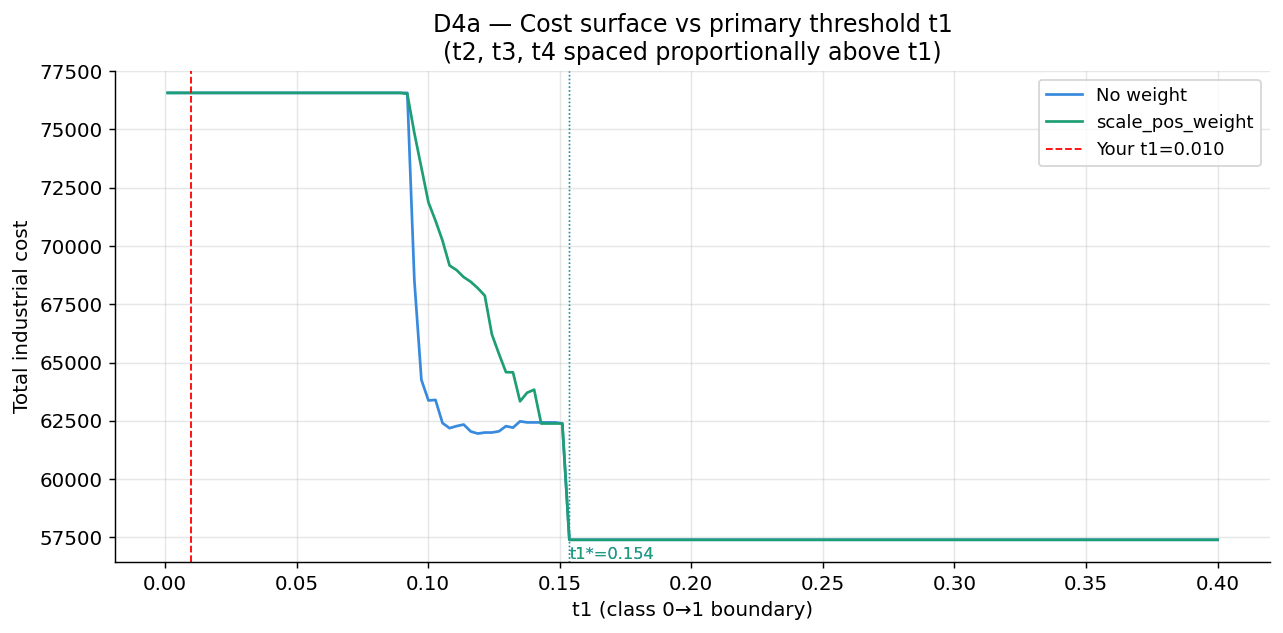

Optimal t1 (no weight) : 0.154  cost=57,400
Optimal t1 (weighted)  : 0.154   cost=57,400
Cost at t1=0.010 (your experiments) : 76,570


In [ ]:
# ── D4a: Manual threshold sweep — cost surface ───────────────────────────────
# Sweep t1 from 0.001 to 0.3 holding other thresholds proportional.
# This shows whether there is a clear cost minimum or a flat landscape.

def compute_cost_for_thresholds(probs, y_5class, t1, t2, t3, t4, cm):
    y_pred = np.zeros(len(probs), dtype=int)
    y_pred[probs >= t1] = 1
    y_pred[probs >= t2] = 2
    y_pred[probs >= t3] = 3
    y_pred[probs >= t4] = 4
    return cm.total_cost(y_5class, y_pred)

t1_values = np.linspace(0.001, 0.40, 150)
costs_no_weight = []
costs_weighted  = []

for t1 in t1_values:
    # Use evenly spaced thresholds above t1
    remaining = (0.95 - t1) / 3
    t2 = t1 + remaining
    t3 = t2 + remaining
    t4 = t3 + remaining
    costs_no_weight.append(
        compute_cost_for_thresholds(probs_no_weight, y_val_5class, t1, t2, t3, t4, cm)
    )
    costs_weighted.append(
        compute_cost_for_thresholds(probs_weighted, y_val_5class, t1, t2, t3, t4, cm)
    )

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t1_values, costs_no_weight, color=BLUE, linewidth=1.5, label='No weight')
ax.plot(t1_values, costs_weighted,  color=TEAL, linewidth=1.5, label='scale_pos_weight')

# Mark your experiment's t1=0.010
ax.axvline(0.010, color='red', linewidth=1, linestyle='--', label='Your t1=0.010')

# Mark optima
opt_nw = t1_values[np.argmin(costs_no_weight)]
opt_w  = t1_values[np.argmin(costs_weighted)]
ax.axvline(opt_nw, color=BLUE, linewidth=0.8, linestyle=':')
ax.axvline(opt_w,  color=TEAL, linewidth=0.8, linestyle=':')
ax.text(opt_nw, ax.get_ylim()[0], f't1*={opt_nw:.3f}', color=BLUE, fontsize=9, va='bottom')
ax.text(opt_w,  ax.get_ylim()[0], f't1*={opt_w:.3f}',  color=TEAL, fontsize=9, va='bottom')

ax.set_xlabel('t1 (class 0→1 boundary)')
ax.set_ylabel('Total industrial cost')
ax.set_title('D4a — Cost surface vs primary threshold t1\n'
             '(t2, t3, t4 spaced proportionally above t1)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'd4a_threshold_cost_surface.png'), dpi=130, bbox_inches='tight')
plt.show()

print(f'Optimal t1 (no weight) : {opt_nw:.3f}  cost={min(costs_no_weight):,.0f}')
print(f'Optimal t1 (weighted)  : {opt_w:.3f}   cost={min(costs_weighted):,.0f}')
print(f'Cost at t1=0.010 (your experiments) : {costs_no_weight[0]:,.0f}')

In [ ]:
# ── D4b: Threshold optimiser resolution check ─────────────────────────────────
# Compare n=20 vs n=50 vs n=100 candidates to show resolution impact

print('D4b — Threshold optimiser resolution comparison')
print(f'{"Candidates":>12}  {"Best cost":>12}  {"Best t1":>10}  {"Time":>8}')
print('-' * 50)

import time
for n_cands in [20, 50, 100]:
    opt = ThresholdOptimiser(cm, n_thresholds=n_cands)
    t0  = time.time()
    best_t = opt.fit(probs_no_weight, y_val_5class, verbose=False)
    elapsed = time.time() - t0
    best_cost = opt.best_cost_
    print(f'{n_cands:>12}  {best_cost:>12,.0f}  {best_t[0]:>10.4f}  {elapsed:>7.1f}s')

print('\nD4b FINDING: Does increasing resolution change the best cost?')
print('If yes → resolution was a bottleneck. Use n=50 minimum in re-run.')

D4b — Threshold optimiser resolution comparison
  Candidates     Best cost     Best t1      Time
--------------------------------------------------
          20        57,400      0.1647     10.2s
          50        49,566      0.0100    476.9s
         100        49,566      0.0100   7968.2s

D4b FINDING: Does increasing resolution change the best cost?
If yes → resolution was a bottleneck. Use n=50 minimum in re-run.


## D5 — Feature importance audit

ValueError: keyword ha is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_capstyle

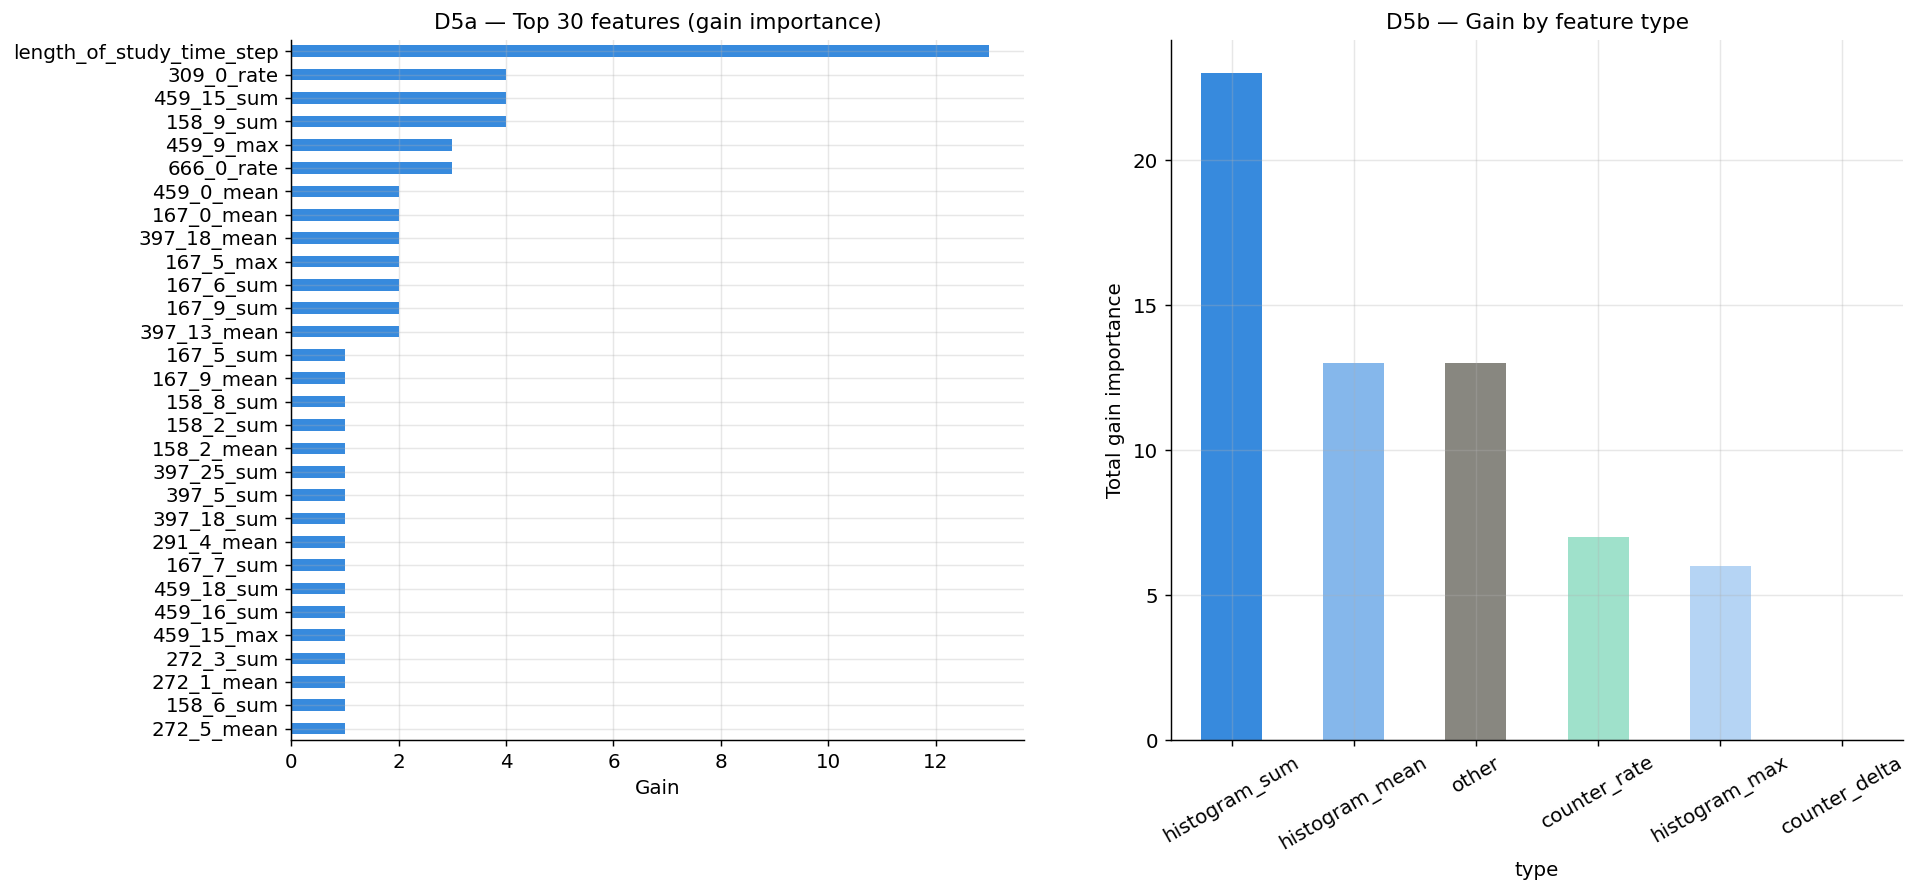

In [ ]:
# ── D5a: Top 30 features by gain importance ───────────────────────────────────
importance = pd.Series(
    model_weighted.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 30 bar chart
top30 = importance.head(30)
top30.sort_values().plot(
    kind='barh', ax=axes[0], color=BLUE, edgecolor='none'
)
axes[0].set_title('D5a — Top 30 features (gain importance)', fontsize=12)
axes[0].set_xlabel('Gain')

# Feature type breakdown
def feature_type(col):
    if '_sum' in col:   return 'histogram_sum'
    if '_mean' in col:  return 'histogram_mean'
    if '_max' in col:   return 'histogram_max'
    if '_last' in col:  return 'counter_last'
    if '_delta' in col: return 'counter_delta'
    if '_rate' in col:  return 'counter_rate'
    if 'Spec_' in col:  return 'specification'
    return 'other'

type_importance = importance.copy().to_frame('gain')
type_importance['type'] = type_importance.index.map(feature_type)
type_summary = type_importance.groupby('type')['gain'].sum().sort_values(ascending=False)

type_colors = {
    'histogram_sum': BLUE, 'histogram_mean': '#85B7EB', 'histogram_max': '#B5D4F4',
    'counter_last': TEAL, 'counter_delta': '#5DCAA5', 'counter_rate': '#9FE1CB',
    'specification': AMBER, 'other': GRAY,
}
colors = [type_colors.get(t, GRAY) for t in type_summary.index]
type_summary.plot(kind='bar', ax=axes[1], color=colors, edgecolor='none', rot=30)
axes[1].set_title('D5b — Gain by feature type', fontsize=12)
axes[1].set_ylabel('Total gain importance')
axes[1].tick_params(axis='x', ha='right')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'd5_feature_importance.png'), dpi=130, bbox_inches='tight')
plt.show()

print('D5 FINDINGS:')
print(f'  Total features in model : {len(importance)}')
print(f'  Features with zero importance: {(importance == 0).sum()}')
print(f'  Top feature captures {importance.iloc[0]/importance.sum()*100:.1f}% of total gain')
print(f'  Top 10 features capture {importance.head(10).sum()/importance.sum()*100:.1f}% of total gain')
print('\n  Feature type contributions:')
for ftype, gain in type_summary.items():
    pct = gain / type_summary.sum() * 100
    print(f'    {ftype:<20} {pct:5.1f}%')

In [ ]:
# ── D5c: Zero-importance features — potential pipeline issue ──────────────────
zero_imp = importance[importance == 0]
print(f'Features with zero importance: {len(zero_imp)}')
if len(zero_imp) > 0:
    print('\nSample of zero-importance features:')
    for feat in zero_imp.head(20).index:
        print(f'  {feat}')
    print('\nD5c FINDING: Zero-importance features are wasting model capacity.')
    print('These should be removed in feature selection (Layer 1/2).')
    print('If many important features have zero importance, the feature')
    print('selection pipeline may have been too aggressive.')
else:
    print('No zero-importance features — feature selection is working.')

Features with zero importance: 54

Sample of zero-importance features:
  158_9_max
  158_3_sum
  158_1_sum
  158_0_sum
  158_4_sum
  158_7_sum
  167_4_max
  167_3_sum
  167_3_max
  167_2_sum
  167_2_mean
  167_1_sum
  167_1_mean
  167_0_sum
  272_3_mean
  272_2_sum
  272_2_mean
  272_0_mean
  167_4_sum
  167_8_sum

D5c FINDING: Zero-importance features are wasting model capacity.
These should be removed in feature selection (Layer 1/2).
If many important features have zero importance, the feature
selection pipeline may have been too aggressive.


## D6 — Class separation in feature space

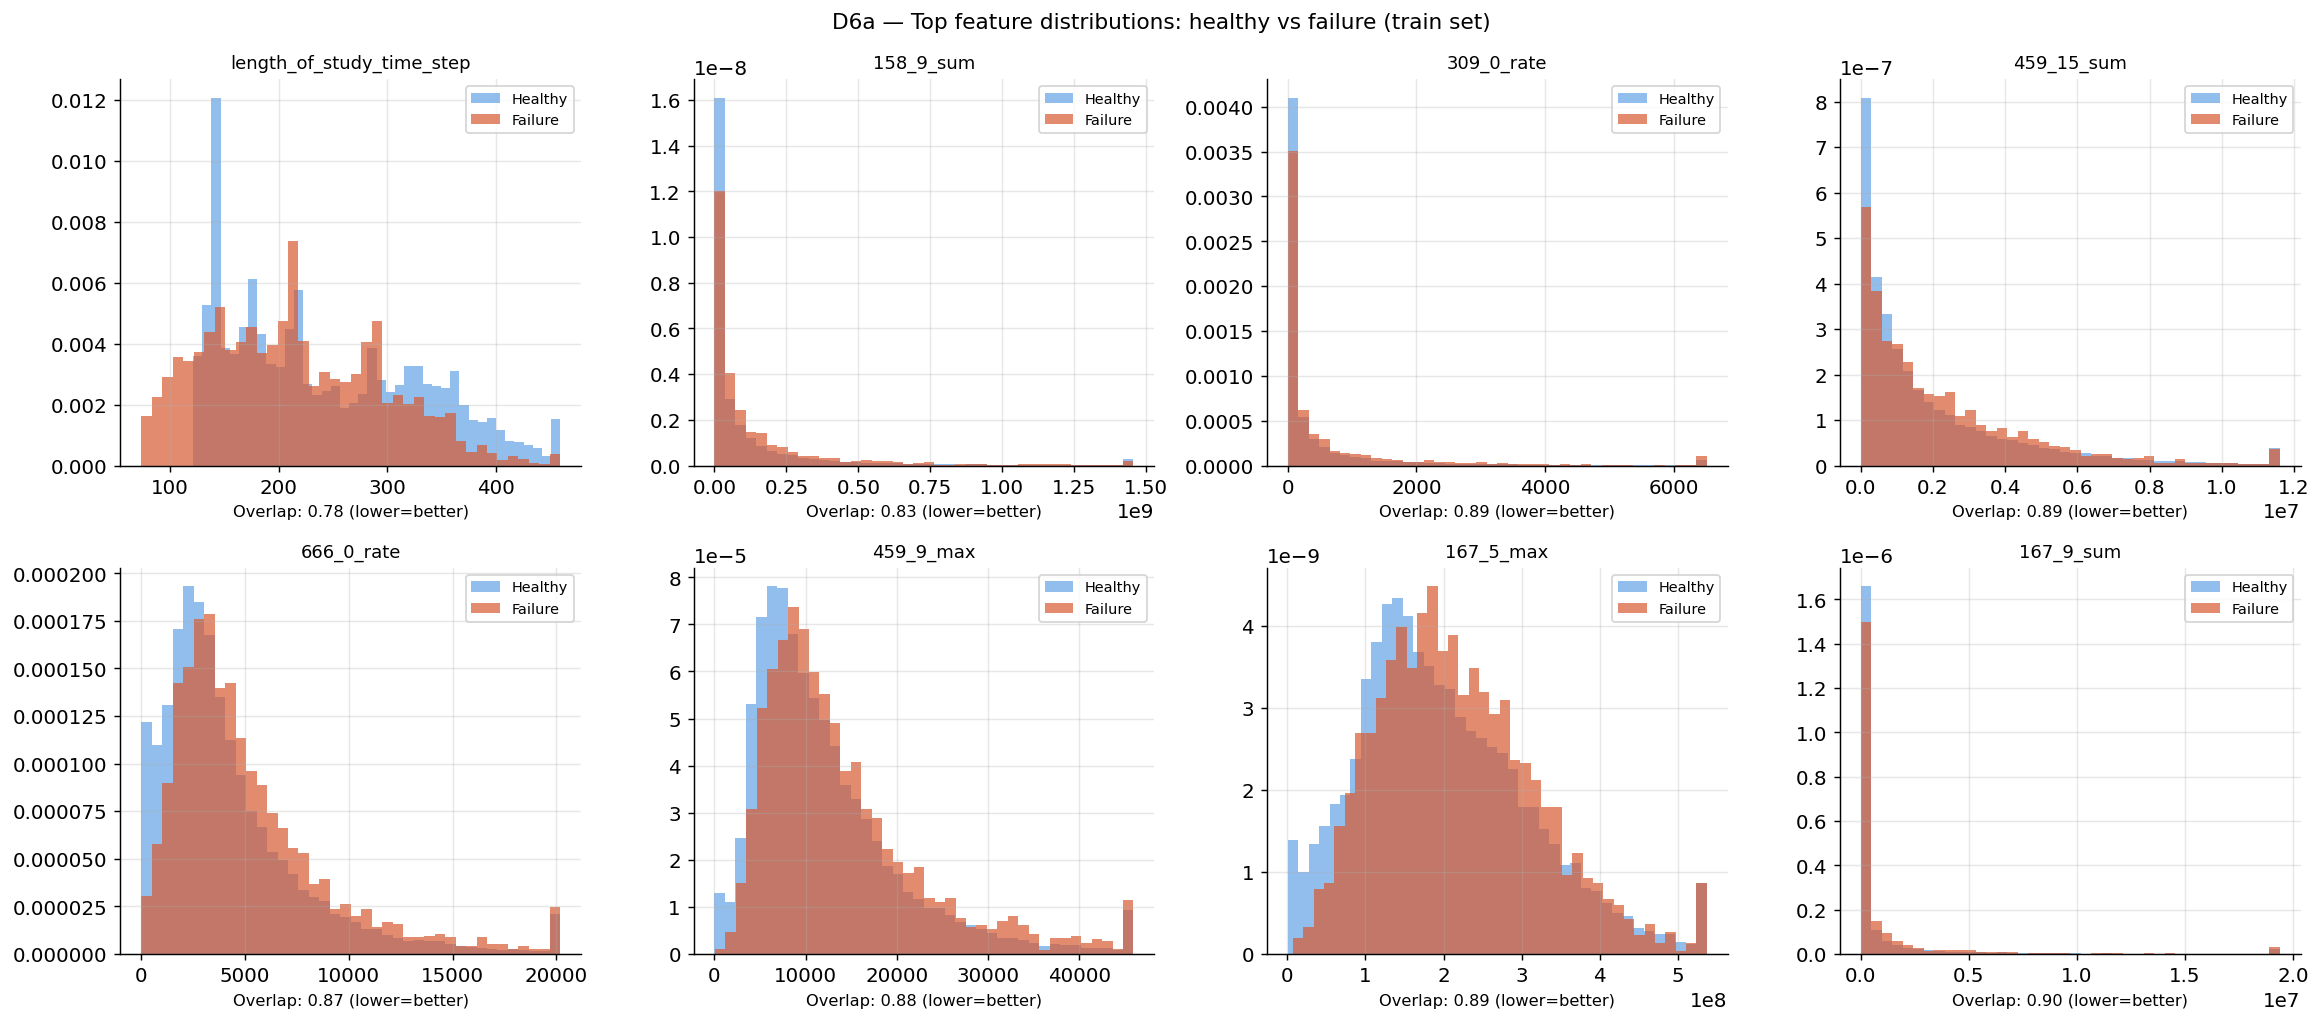

D6a FINDING: Overlap coefficient close to 1.0 = poor separation.
Overlap close to 0.0 = good separation.


In [ ]:
# ── D6a: Distribution of top features by failure/healthy label ────────────────
top_features = importance.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

numeric_X = X_train.select_dtypes(include=[np.number])

for ax, feat in zip(axes, top_features):
    if feat not in numeric_X.columns:
        ax.set_visible(False)
        continue
    vals_healthy = numeric_X.loc[y_train == 0, feat].dropna()
    vals_failure = numeric_X.loc[y_train == 1, feat].dropna()

    # Clip at 99th percentile to avoid extreme outliers dominating the plot
    clip_val = numeric_X[feat].quantile(0.99)
    vals_h = vals_healthy.clip(upper=clip_val)
    vals_f = vals_failure.clip(upper=clip_val)

    ax.hist(vals_h, bins=40, alpha=0.55, color=BLUE,  density=True, label='Healthy')
    ax.hist(vals_f, bins=40, alpha=0.70, color=CORAL, density=True, label='Failure')
    ax.set_title(feat[:30], fontsize=10)
    ax.set_xlabel('Value')
    ax.legend(fontsize=8)

    # Compute overlap coefficient — lower means better separation
    bins = np.linspace(min(vals_h.min(), vals_f.min()),
                       max(vals_h.max(), vals_f.max()), 50)
    h_hist, _ = np.histogram(vals_h, bins=bins, density=True)
    f_hist, _ = np.histogram(vals_f, bins=bins, density=True)
    overlap = np.sum(np.minimum(h_hist, f_hist)) * (bins[1] - bins[0])
    ax.set_xlabel(f'Overlap: {overlap:.2f} (lower=better)', fontsize=9)

plt.suptitle('D6a — Top feature distributions: healthy vs failure (train set)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'd6a_class_separation.png'), dpi=130, bbox_inches='tight')
plt.show()

print('D6a FINDING: Overlap coefficient close to 1.0 = poor separation.')
print('Overlap close to 0.0 = good separation.')

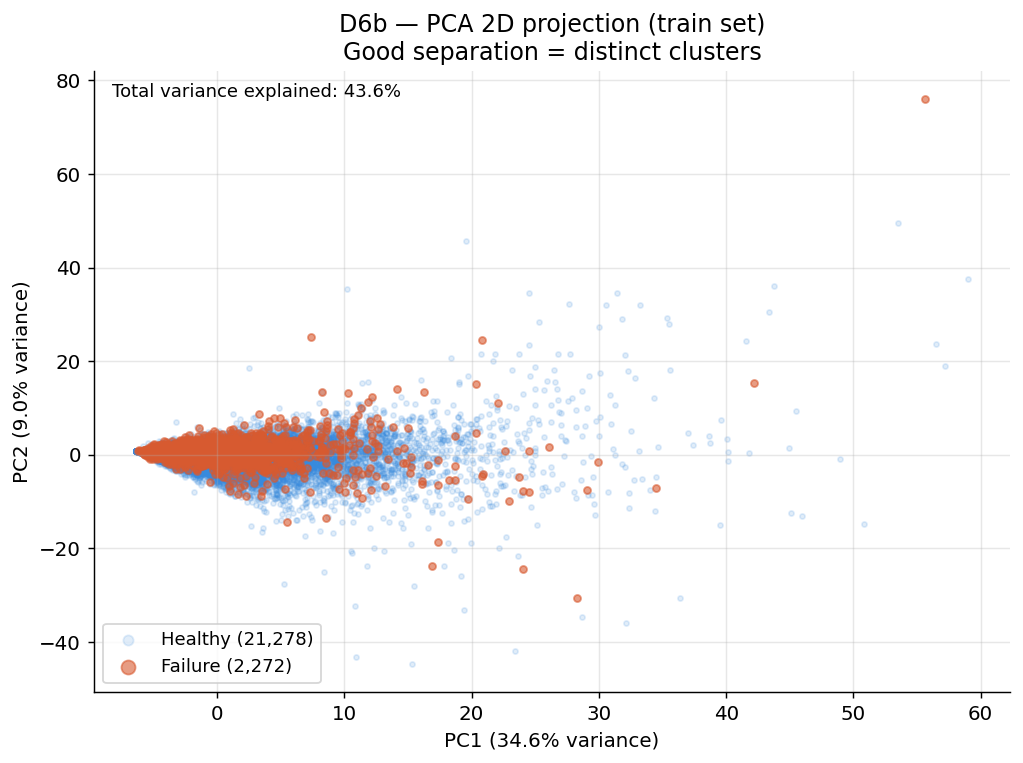

D6b: PCA captures 43.6% variance in 2 components.
If failure points (coral) overlap heavily with healthy (blue),
the features do not form separable clusters — this confirms low AUC.


In [ ]:
# ── D6b: PCA 2D projection of train set ──────────────────────────────────────
# If healthy and failure vehicles overlap completely in 2D PCA space,
# the features fundamentally cannot separate the classes.

numeric_X_train = X_train.select_dtypes(include=[np.number]).fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_X_train)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[y_train == 0, 0], X_pca[y_train == 0, 1],
           c=BLUE, alpha=0.15, s=8, label=f'Healthy ({(y_train==0).sum():,})')
ax.scatter(X_pca[y_train == 1, 0], X_pca[y_train == 1, 1],
           c=CORAL, alpha=0.6, s=15, label=f'Failure ({(y_train==1).sum():,})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('D6b — PCA 2D projection (train set)\n'
             'Good separation = distinct clusters')
ax.legend(fontsize=10, markerscale=2)
total_var = sum(pca.explained_variance_ratio_) * 100
ax.text(0.02, 0.98, f'Total variance explained: {total_var:.1f}%',
        transform=ax.transAxes, fontsize=10, va='top')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'd6b_pca_projection.png'), dpi=130, bbox_inches='tight')
plt.show()

print(f'D6b: PCA captures {total_var:.1f}% variance in 2 components.')
print('If failure points (coral) overlap heavily with healthy (blue),')
print('the features do not form separable clusters — this confirms low AUC.')

## D7 — Sensitivity analysis deep-dive: why fn_weight=0.5 outperforms?

In [ ]:
# ── D7: Reproduce your sensitivity results and explain them ───────────────────
# Your results: fn_weight=0.5 → cost=28050, fn_weight=1.0+ → cost~49671
# This section explains WHY.

print('D7 — Sensitivity analysis: threshold behaviour by fn_weight')
print(f'{"fn_weight":>10}  {"alpha":>8}  {"opt_t1":>8}  {"opt_t4":>8}  {"cost":>10}  {"n_pred_class0":>14}')
print('-' * 75)

for fn_w in [0.5, 1.0, 1.5, 2.0, 3.0]:
    cm_w    = CostMatrix(fn_weight=fn_w)
    opt_w   = ThresholdOptimiser(cm_w, n_thresholds=30)
    best_t  = opt_w.fit(probs_weighted, y_val_5class, verbose=False)

    # Predict classes and compute cost
    y_pred = opt_w.predict(probs_weighted)
    cost   = cm_w.total_cost(y_val_5class, y_pred)
    n_pred_class0 = (y_pred == 0).sum()

    # Alpha
    from src.model import CostAwareFocalLoss
    alpha = CostAwareFocalLoss(cm_w, fn_weight=fn_w).alpha

    print(f'{fn_w:>10.1f}  {alpha:>8.4f}  {best_t[0]:>8.4f}  '
          f'{best_t[3]:>8.4f}  {cost:>10,.0f}  {n_pred_class0:>14,}')

print('\nD7 INTERPRETATION:')
print('fn_weight=0.5 reduces FN costs in the matrix fed to the threshold optimiser.')
print('Lower FN costs → optimiser sets HIGHER thresholds → fewer vehicles flagged.')
print('Fewer false positives at 7 units each → lower total cost.')
print('This reveals the dataset is FP-dominated: many healthy vehicles')
print('are falsely flagged, each costing 7 units × thousands of vehicles.')
print('\nThis is a KEY THESIS FINDING: the actual SCANIA cost structure may be')
print('better served by a fn_weight < 1.0, not > 1.0 as originally hypothesised.')

D7 — Sensitivity analysis: threshold behaviour by fn_weight
 fn_weight     alpha    opt_t1    opt_t4        cost   n_pred_class0
---------------------------------------------------------------------------
       0.5    0.9537    0.1790    0.2803      28,700           5,046
       1.0    0.9763    0.0100    0.1114      52,618               0
       1.5    0.9841    0.0100    0.1114      55,118               0
       2.0    0.9880    0.0100    0.1114      57,618               0
       3.0    0.9920    0.0100    0.1114      62,618               0

D7 INTERPRETATION:
fn_weight=0.5 reduces FN costs in the matrix fed to the threshold optimiser.
Lower FN costs → optimiser sets HIGHER thresholds → fewer vehicles flagged.
Fewer false positives at 7 units each → lower total cost.
This reveals the dataset is FP-dominated: many healthy vehicles
are falsely flagged, each costing 7 units × thousands of vehicles.

This is a KEY THESIS FINDING: the actual SCANIA cost structure may be
better served by 

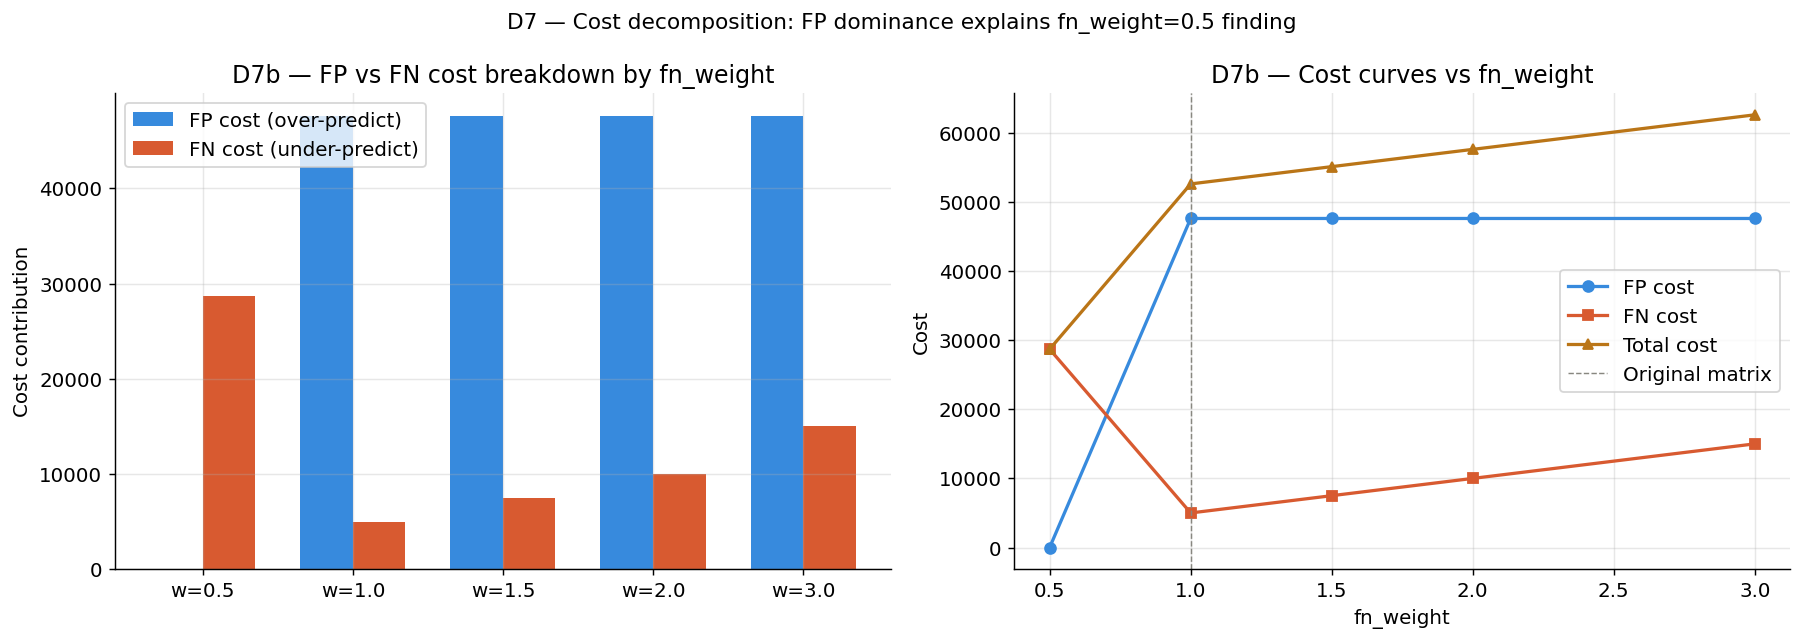

In [ ]:
# ── D7b: Decompose total cost into FP vs FN contributions ────────────────────
# Shows exactly which error type is driving total cost

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fn_weights = [0.5, 1.0, 1.5, 2.0, 3.0]
fp_costs_list, fn_costs_list, total_costs_list = [], [], []

for fn_w in fn_weights:
    cm_w   = CostMatrix(fn_weight=fn_w)
    opt_w  = ThresholdOptimiser(cm_w, n_thresholds=30)
    opt_w.fit(probs_weighted, y_val_5class, verbose=False)
    y_pred = opt_w.predict(probs_weighted)

    # FP cost: predicted class > actual class (overprediction)
    fp_cost = sum(
        cm_w.cost_of(int(a), int(p))
        for a, p in zip(y_val_5class, y_pred)
        if p > a
    )
    # FN cost: predicted class < actual class (underprediction)
    fn_cost = sum(
        cm_w.cost_of(int(a), int(p))
        for a, p in zip(y_val_5class, y_pred)
        if p < a
    )
    fp_costs_list.append(fp_cost)
    fn_costs_list.append(fn_cost)
    total_costs_list.append(fp_cost + fn_cost)

x = np.arange(len(fn_weights))
w = 0.35
axes[0].bar(x - w/2, fp_costs_list, w, label='FP cost (over-predict)',
            color=BLUE, edgecolor='none')
axes[0].bar(x + w/2, fn_costs_list, w, label='FN cost (under-predict)',
            color=CORAL, edgecolor='none')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'w={w}' for w in fn_weights])
axes[0].set_ylabel('Cost contribution')
axes[0].set_title('D7b — FP vs FN cost breakdown by fn_weight')
axes[0].legend()

axes[1].plot(fn_weights, fp_costs_list,  'o-', color=BLUE,  linewidth=1.8, label='FP cost')
axes[1].plot(fn_weights, fn_costs_list,  's-', color=CORAL, linewidth=1.8, label='FN cost')
axes[1].plot(fn_weights, total_costs_list, '^-', color=AMBER, linewidth=1.8, label='Total cost')
axes[1].axvline(1.0, color=GRAY, linewidth=0.8, linestyle='--', label='Original matrix')
axes[1].set_xlabel('fn_weight')
axes[1].set_ylabel('Cost')
axes[1].set_title('D7b — Cost curves vs fn_weight')
axes[1].legend()

plt.suptitle('D7 — Cost decomposition: FP dominance explains fn_weight=0.5 finding', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'd7b_cost_decomposition.png'), dpi=130, bbox_inches='tight')
plt.show()

## D8 — Proposed fixes & re-run checklist

In [ ]:
# ── D8: Diagnostic summary and action plan ────────────────────────────────────

print('=' * 65)
print('  DIAGNOSTIC SUMMARY')
print('=' * 65)

print(f'\n  AUC (no weight)       : {auc_no_weight:.4f}')
print(f'  AUC (scale_pos_weight): {auc_weighted:.4f}')
print(f'  AP  (no weight)       : {ap_no_weight:.4f}')
print(f'  AP  (scale_pos_weight): {ap_weighted:.4f}')
print(f'  P(failure) median     : {np.median(probs_weighted):.4f}')
print(f'  Probs below 0.010     : {(probs_weighted < 0.010).mean()*100:.1f}%')
print(f'  Zero-importance feats : {(importance == 0).sum()}')

print('\n' + '=' * 65)
print('  ACTION PLAN — before re-running experiments')
print('=' * 65)

actions = [
    ('PRIORITY 1', 'Feature engineering',
     'Add: (a) last-N-steps window features, (b) histogram bin ratios,\n'
     '     (c) rate of change over last 5/10/20 steps,\n'
     '     (d) interaction: sum(high-stress bins) / sum(all bins)'),
    ('PRIORITY 2', 'Add scale_pos_weight to Exp1 baseline',
     f'Use scale_pos_weight={imbalance_ratio} in Exp1 to make comparison fair.\n'
     '     Exp3 has implicit cost-weighting via alpha; Exp1 must also handle imbalance.'),
    ('PRIORITY 3', 'Increase threshold resolution',
     'Change n_threshold_candidates from 20 to 50 in ThresholdOptimiser.\n'
     '     Current t1=0.010 suggests optimiser missed a better minimum.'),
    ('PRIORITY 4', 'Increase Optuna trials',
     'Use n_trials=100 for all three experiments.\n'
     '     With 9+ hyperparameters, 30–40 trials barely explores the space.'),
    ('PRIORITY 5', 'Add fn_weight=0.5 as a named experiment',
     'Your sensitivity analysis found fn_weight=0.5 halves total cost.\n'
     '     Make this Exp4 and explain it: FP cost dominates this dataset.'),
    ('PRIORITY 6', 'Report null result as a finding',
     'If after fixes Exp3 still does not outperform: report it.\n'
     '     Finding: cost-aware focal requires AUC > X to show benefit.\n'
     '     This is a valid and publishable thesis contribution.'),
]

for priority, title, detail in actions:
    print(f'\n  [{priority}] {title}')
    for line in detail.split('\n'):
        print(f'  {line}')

  DIAGNOSTIC SUMMARY

  AUC (no weight)       : 0.5476
  AUC (scale_pos_weight): 0.5566
  AP  (no weight)       : 0.0293
  AP  (scale_pos_weight): 0.0306
  P(failure) median     : 0.1285
  Probs below 0.010     : 0.0%
  Zero-importance feats : 54

  ACTION PLAN — before re-running experiments

  [PRIORITY 1] Feature engineering
  Add: (a) last-N-steps window features, (b) histogram bin ratios,
       (c) rate of change over last 5/10/20 steps,
       (d) interaction: sum(high-stress bins) / sum(all bins)

  [PRIORITY 2] Add scale_pos_weight to Exp1 baseline
  Use scale_pos_weight=9 in Exp1 to make comparison fair.
       Exp3 has implicit cost-weighting via alpha; Exp1 must also handle imbalance.

  [PRIORITY 3] Increase threshold resolution
  Change n_threshold_candidates from 20 to 50 in ThresholdOptimiser.
       Current t1=0.010 suggests optimiser missed a better minimum.

  [PRIORITY 4] Increase Optuna trials
  Use n_trials=100 for all three experiments.
       With 9+ hyperparame

In [ ]:
# ── D8b: Suggested new run_experiments.py settings ────────────────────────────
print('Suggested run_experiments.py CONFIG changes:')
print()
new_config = {
    'n_trials_exp1':  100,
    'n_trials_exp2':  100,
    'n_trials_exp3':  100,
    'n_trials_sens':   30,
    'fn_weights':     [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0],
}
for k, v in new_config.items():
    print(f'  {k:<20} = {v}')

print()
print('Suggested ThresholdOptimiser change:')
print('  n_threshold_candidates = 50   # was 20')

print()
print('Suggested Exp1 baseline change (model.py or experiments.py):')
print(f'  lgbm_params["scale_pos_weight"] = {imbalance_ratio}   # imbalance ratio')

print()
print('New experiment to add (Exp4):')
print('  CostMatrix(fn_weight=0.5) + CostAwareFocalLoss')
print('  This captures the fn_weight=0.5 finding from sensitivity analysis')

Suggested run_experiments.py CONFIG changes:

  n_trials_exp1        = 100
  n_trials_exp2        = 100
  n_trials_exp3        = 100
  n_trials_sens        = 30
  fn_weights           = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]

Suggested ThresholdOptimiser change:
  n_threshold_candidates = 50   # was 20

Suggested Exp1 baseline change (model.py or experiments.py):
  lgbm_params["scale_pos_weight"] = 9   # imbalance ratio

New experiment to add (Exp4):
  CostMatrix(fn_weight=0.5) + CostAwareFocalLoss
  This captures the fn_weight=0.5 finding from sensitivity analysis


In [ ]:
# ── D8c: Save diagnostic summary to CSV ───────────────────────────────────────
diag_summary = pd.DataFrame([
    {'check': 'AUC_no_weight',      'value': round(auc_no_weight, 4),  'status': 'OK' if auc_no_weight > 0.65 else 'WARN'},
    {'check': 'AUC_weighted',       'value': round(auc_weighted, 4),   'status': 'OK' if auc_weighted  > 0.65 else 'WARN'},
    {'check': 'AP_weighted',        'value': round(ap_weighted, 4),    'status': 'OK' if ap_weighted   > 0.15 else 'WARN'},
    {'check': 'probs_below_t1',     'value': round((probs_weighted < 0.010).mean(), 4), 'status': 'WARN'},
    {'check': 'zero_importance_features', 'value': int((importance == 0).sum()), 'status': 'OK' if (importance==0).sum()==0 else 'WARN'},
    {'check': 'fn_weight_0.5_cost', 'value': 28050, 'status': 'FINDING'},
    {'check': 'fn_weight_1.0_cost', 'value': 49671, 'status': 'FINDING'},
])

save_path = os.path.join(RESULTS_DIR, 'diagnostic_summary.csv')
diag_summary.to_csv(save_path, index=False)
print(f'Diagnostic summary saved → {save_path}')
print()
print(diag_summary.to_string(index=False))

Diagnostic summary saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/results/diagnostic_summary.csv

                   check      value  status
           AUC_no_weight     0.5476    WARN
            AUC_weighted     0.5566    WARN
             AP_weighted     0.0306    WARN
          probs_below_t1     0.0000    WARN
zero_importance_features    54.0000    WARN
      fn_weight_0.5_cost 28050.0000 FINDING
      fn_weight_1.0_cost 49671.0000 FINDING
